In [2]:
import numpy as np
import matplotlib as mt
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
import scipy as sc
import scipy.stats as sct
import scipy.optimize as sco
import scipy.spatial as scp
import MDAnalysis as mda
from tqdm import tqdm

#### functions

In [3]:
def get_times(log_file, factor=5e+5):
    for l in open(log_file, 'r'):
        if "GROMACS will be stopped after" in l:
            return float(l.strip().split()[8])/factor
    raise ValueError('not found')

def bootstrap_median(t, subset=0.8, r=50000, seed=None):
    np.random.seed(seed)
    subset = int(len(t)*subset)
    ai = [int(subset/2), int(subset/2 - 0.5)]
    #
    bt = np.zeros((r))
    for a in range(r):
        bt[a] = np.mean( np.sort( np.random.choice(t, subset) ) [ai] )
    #
    return bt

#### raw times

In [47]:
tint = np.zeros((20,15))
for t in range(2):
    for i in range(10):
        for r in range(15):
            tint[t*10+i,r] = get_times(f'2_int_confs/5_relative-residence-times/t{t+1}_i{i+1}/r{r+1}/log_md')

In [54]:
np.save('saved_ramd_/tint.npy', tint)

In [127]:
tbound = np.zeros((32,15))
for a,b in enumerate(range(1,64,2)):
    for r in range(15):
        tbound[a,r] = get_times(f'1_bound_confs/relative-residence-time/b{b}/r{r+1}/log_md')

In [128]:
np.save('saved_ramd_/tbound.npy', tbound)

In [4]:
tint = np.load('saved_ramd_/tint.npy')
tbound = np.load('saved_ramd_/tbound.npy')

### relative residence times

In [5]:
bint = [
    bootstrap_median(t) for t in tint
]

bbound = [
    bootstrap_median(t) for t in tbound
]

In [6]:
mint = np.mean(bint, axis=1), np.std(bint, axis=1)
mbound = np.mean(bbound, axis=1), np.std(bbound, axis=1)

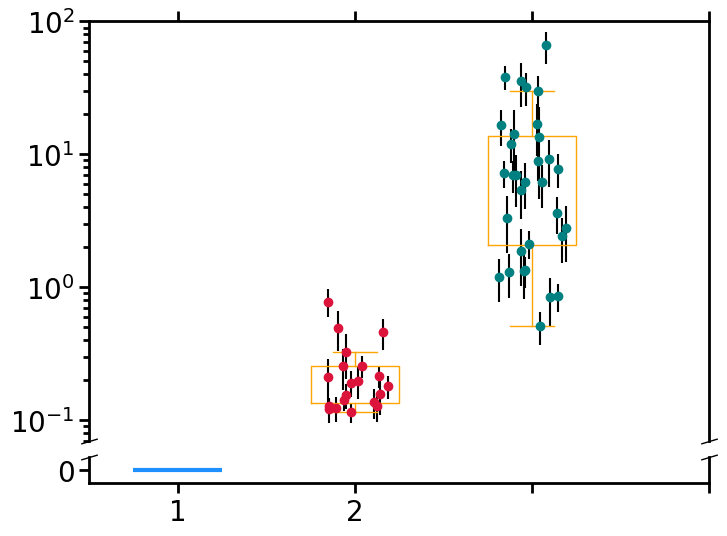

In [15]:
fig,(ax0, ax1) = plt.subplots(2,1, figsize=(8,6), sharex=True, height_ratios=[0.94,0.06])
fig.subplots_adjust(hspace=0.07)
ax0.spines.bottom.set_visible(False)
ax1.spines.top.set_visible(False)
ax0.xaxis.tick_top()
ax0.tick_params(labelbottom=False)
d = .3  
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax0.plot([0, 1], [0, 0], transform=ax0.transAxes, **kwargs)
ax1.plot([0, 1], [1, 1], transform=ax1.transAxes, **kwargs)
#
#
np.random.seed(123456)
ax0.errorbar(0.8+np.random.random(len(mint[0]))/2.5, mint[0], fmt='o', yerr=mint[1], color='crimson', ecolor='black')
ax0.errorbar(1.8+np.random.random(len(mbound[0]))/2.5, mbound[0], fmt='o', yerr=mbound[1], color='teal', ecolor='black')
ax0.hlines(0, 0,3)
ax0.set_yscale('log')
ax0.set_xlim(-0.5,2.5)
ax0.set_ylim(0.07,1e2)
ax0.boxplot([mint[0], mbound[0]], 
           showfliers=False, medianprops={'visible': False}, widths=0.5, boxprops={'color':'orange'},
          whiskerprops={'color':'orange'}, capprops={'color':'orange'})
ax1.hlines(0, -0.25,0.25, lw=3, color='dodgerblue')
ax1.set_yticks([0])
ax1.set_xticks([0,1,2,3])
#
for ax in [ax0,ax1]:
    ax.spines[:].set_linewidth(2)
    ax.tick_params(labelsize=20, length=7, width=2)
    ax.tick_params(which='minor', length=4, width=2)
#
plt.savefig('saved_ramd_/ramd.pdf')
plt.show()

In [12]:
np.mean(mint[0]), np.mean(mint[1])

(0.23933902575000005, 0.06177551345087261)

In [15]:
np.mean(mbound[0]), np.mean(mbound[1])

(11.367669638062502, 3.7252870763674126)

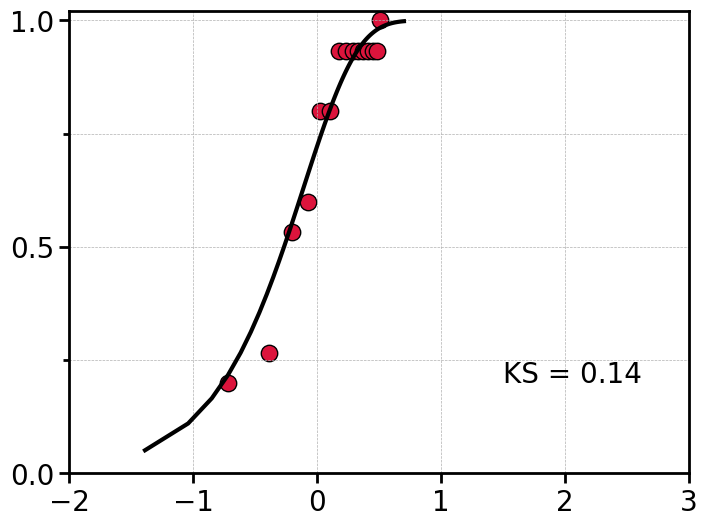

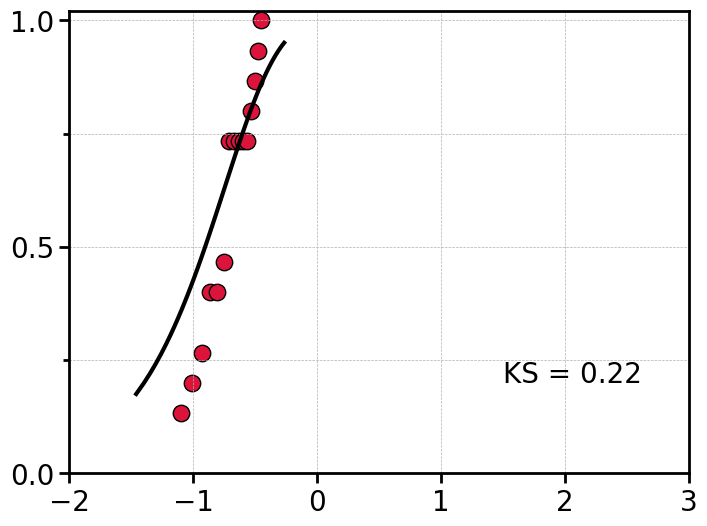

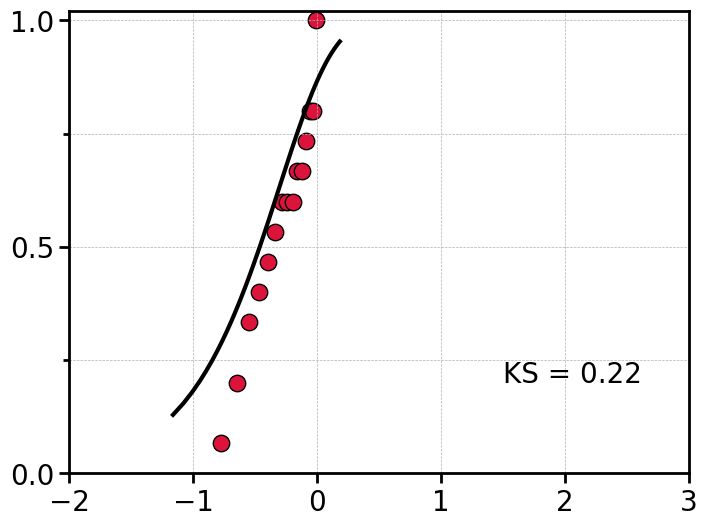

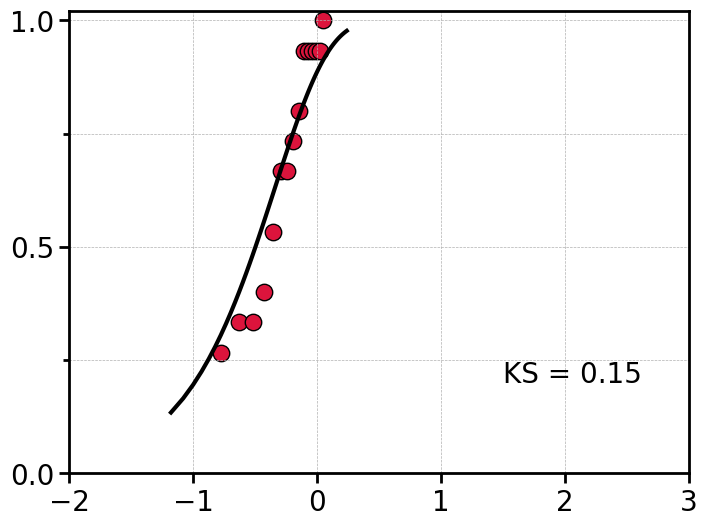

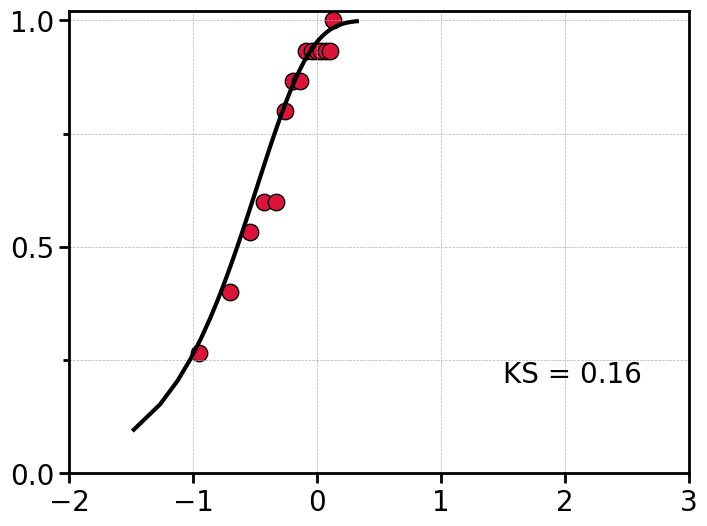

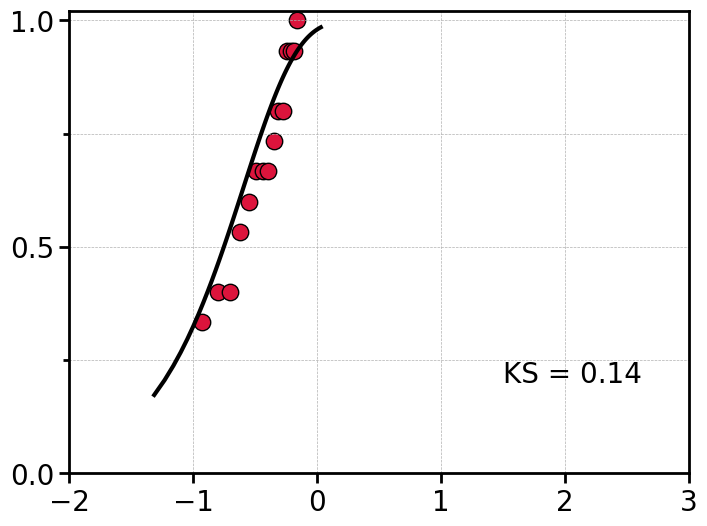

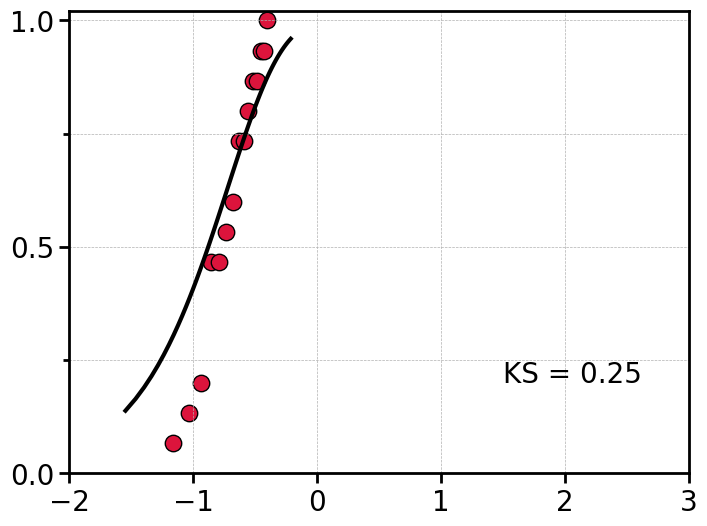

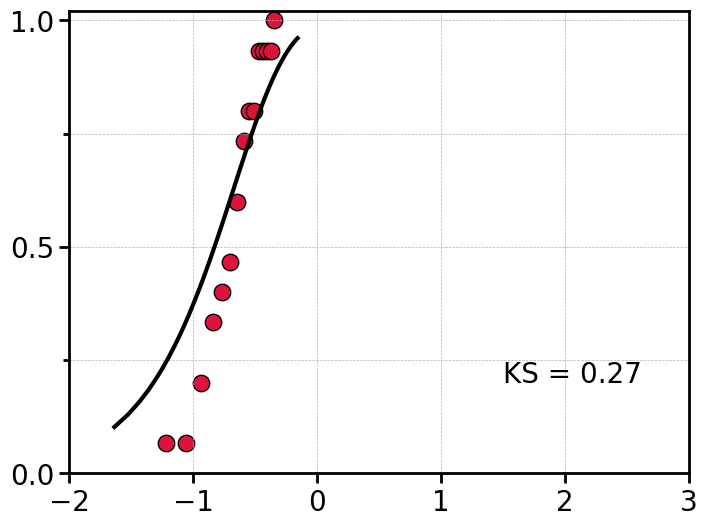

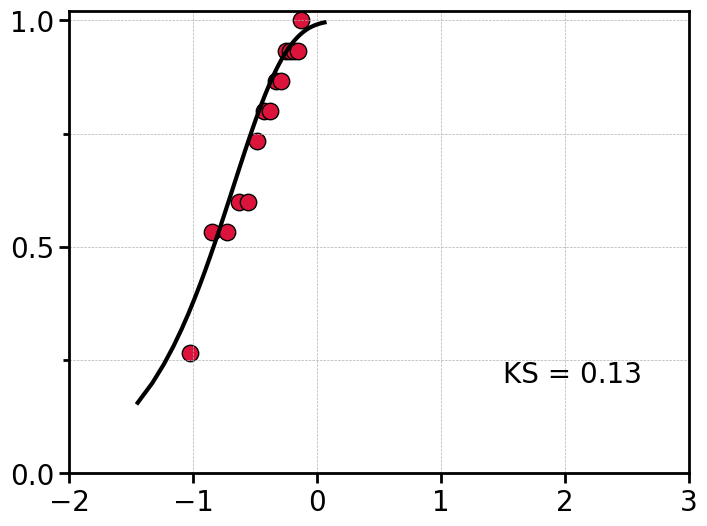

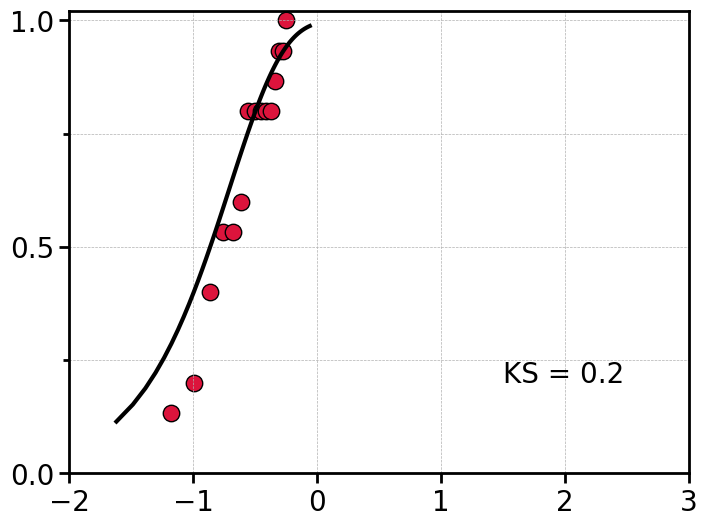

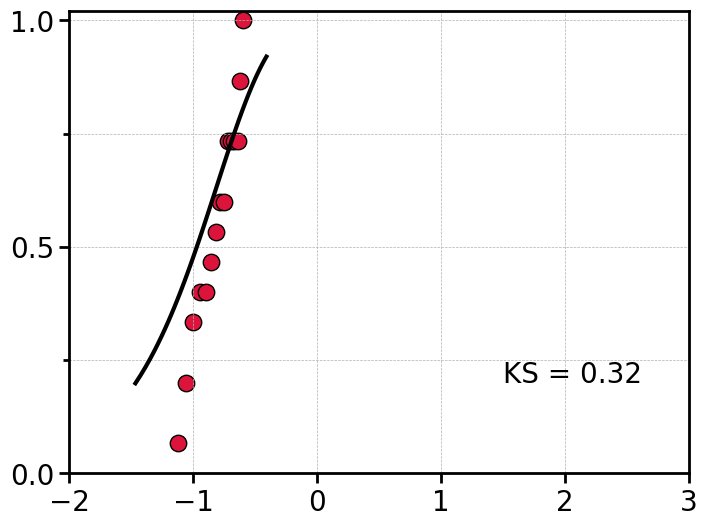

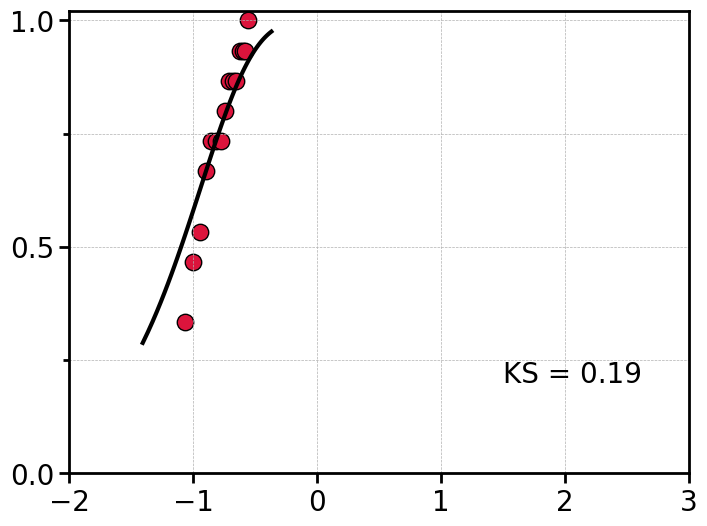

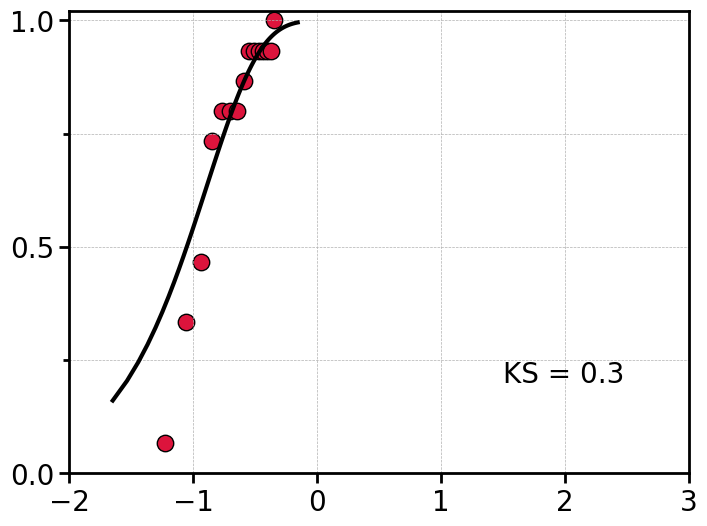

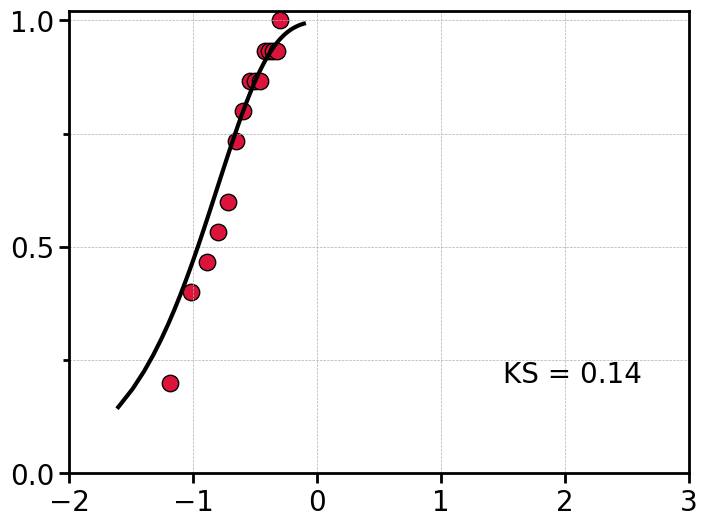

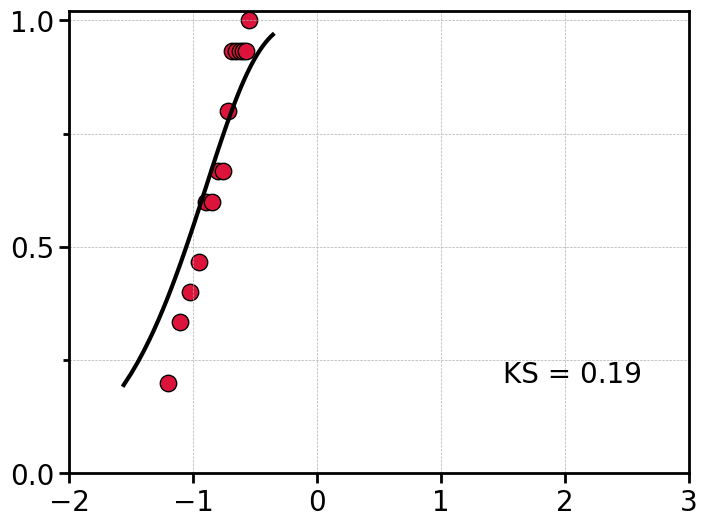

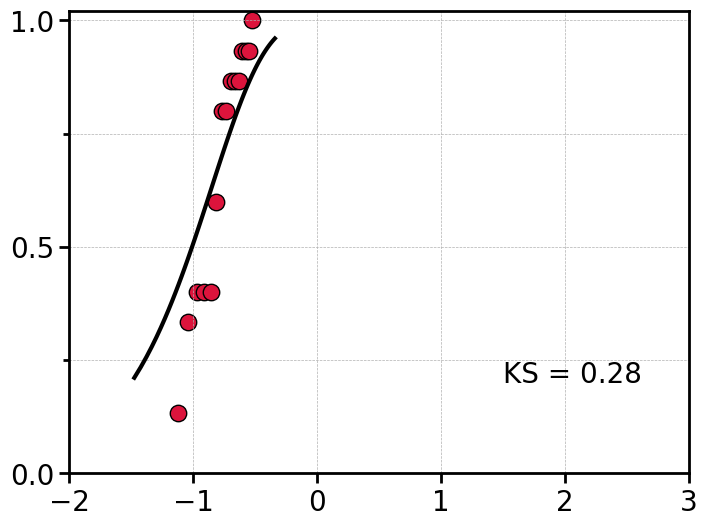

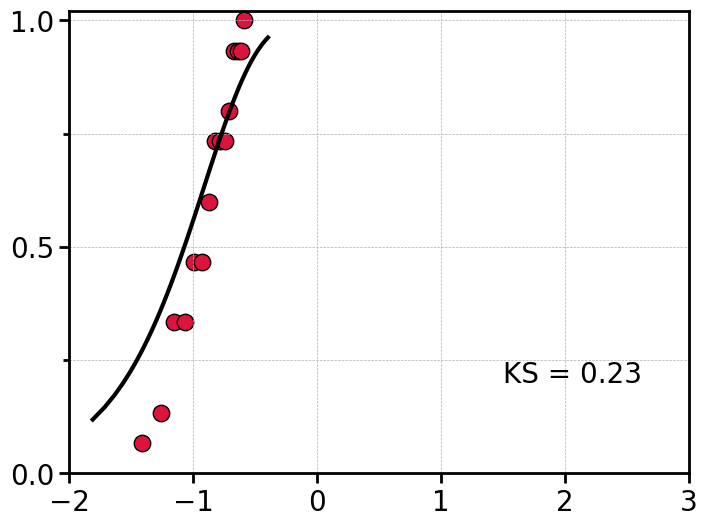

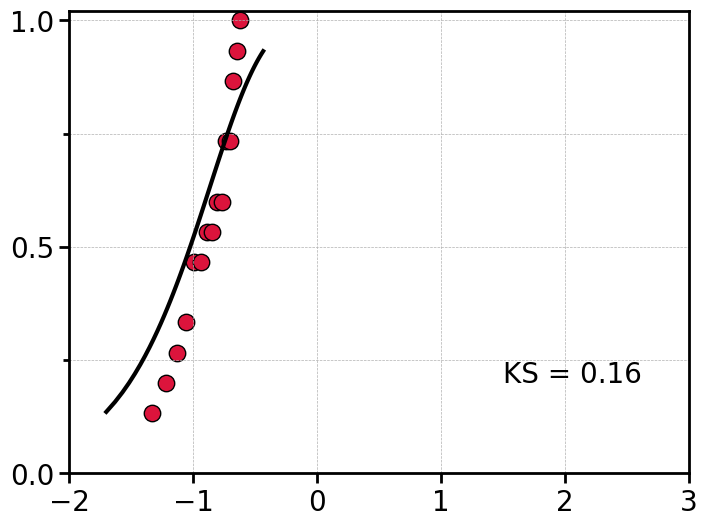

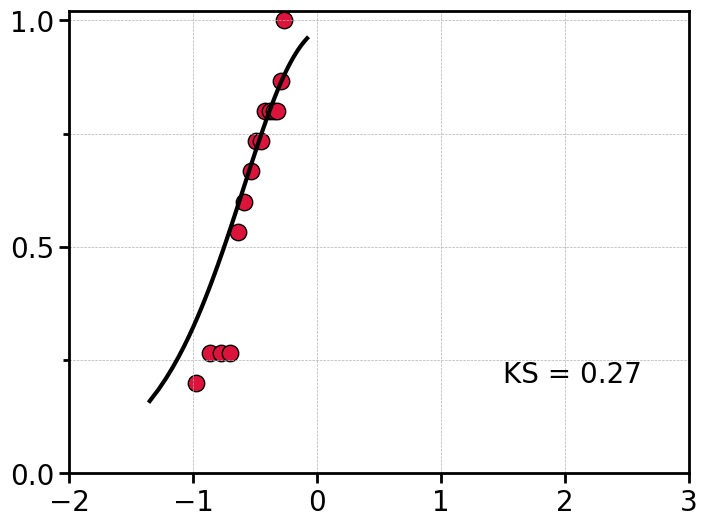

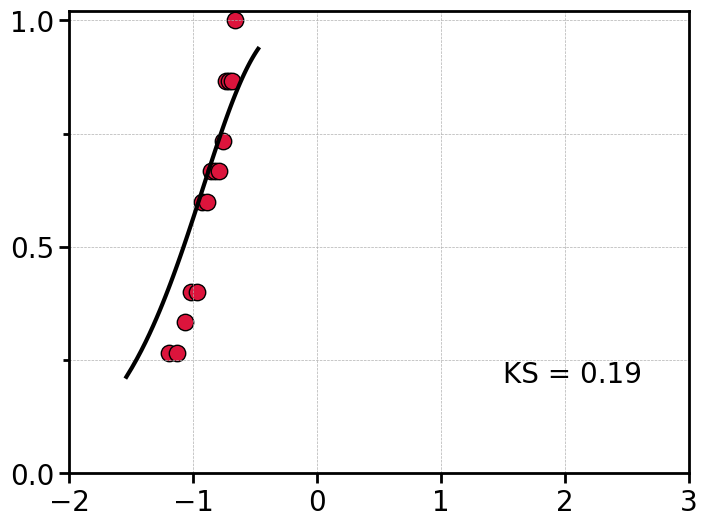

In [32]:
for i in range(len(tint)):
    fig,ax = plt.subplots(1, figsize=(8,6))
    #
    times = tint[i]
    mini, maxi, mean = np.min(times), np.max(times), mint[0][i]
    xp = np.linspace(0.5*mini, 1.5*maxi, 100)
    poisson = 1 - np.exp(-xp/mean)
    npoints = len(times)
    hist, bins = np.histogram(times, bins=npoints)
    bins = bins[1:] - (bins[1]-bins[0])/2
    cumsum = np.cumsum(hist)
    cumsum = cumsum/np.max(cumsum)
    ks = np.round(np.max(np.abs(1-np.exp(-bins/mean)) - cumsum), 2)
    ax.text(1.5,0.2,f'KS = {np.round(ks,2)}', fontsize=20)
    #
    ax.scatter(np.log10(bins), cumsum, marker='o', color='crimson', edgecolor='black', s=140)
    ax.plot(np.log10(xp), poisson, color='black', lw=3)
    ax.set_ylim(0,1.02)
    ax.set_yticks([0,0.5,1])
    ax.set_xlim(np.log10(0.01), np.log10(1e3))
    ax.set_xticks([-2,-1,0,1,2,3])
    ax.grid(linestyle='--', linewidth=0.5, which='both')
    #
    ax.spines[:].set_linewidth(2)
    ax.tick_params(labelsize=20, width=2, length=7)
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(which='minor', length=4, width=2)
    #
    plt.savefig(f'saved_ramd_/ks_plts/int/i{i}.pdf')
    plt.show()

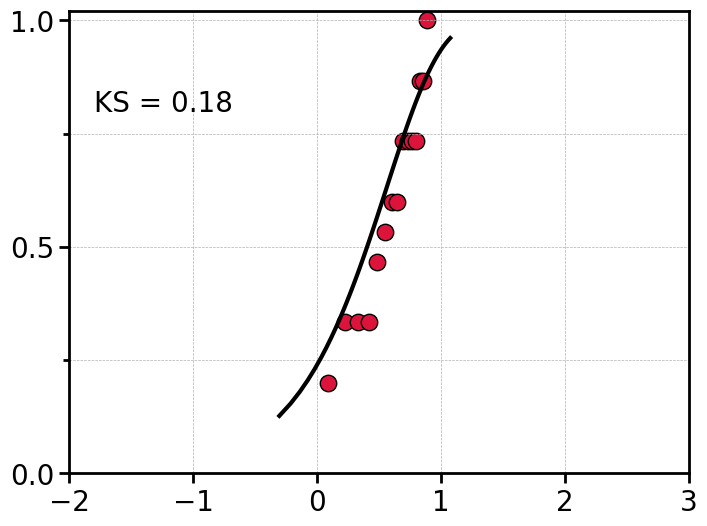

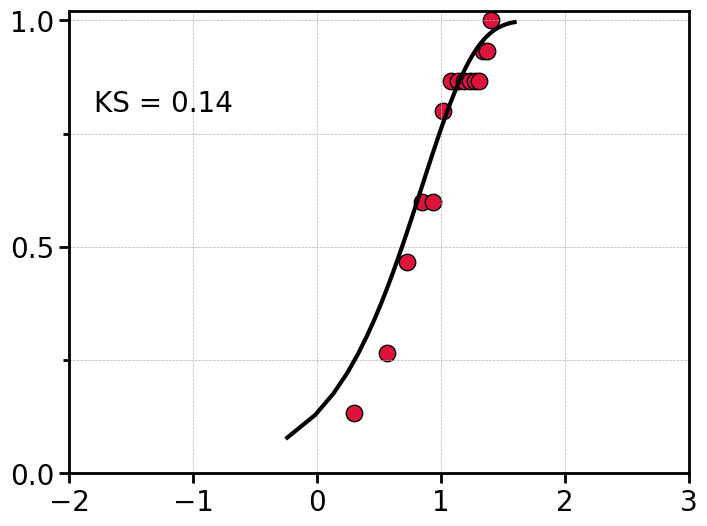

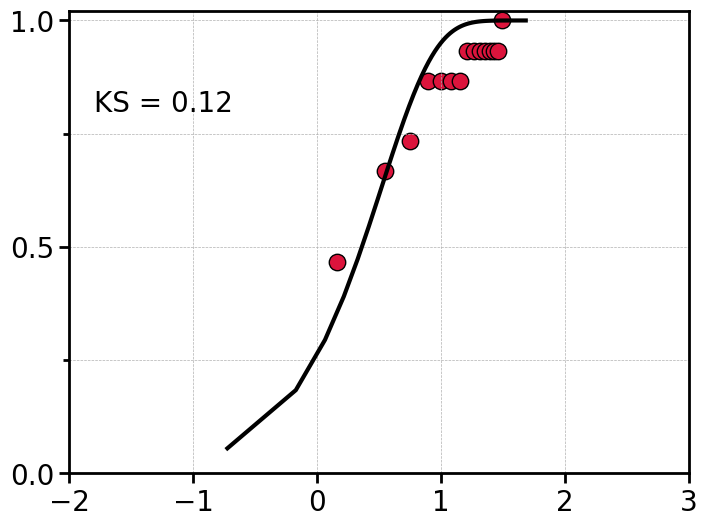

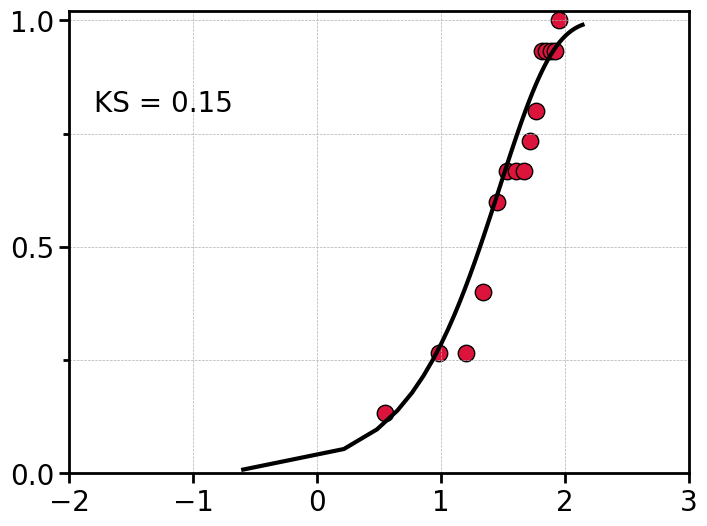

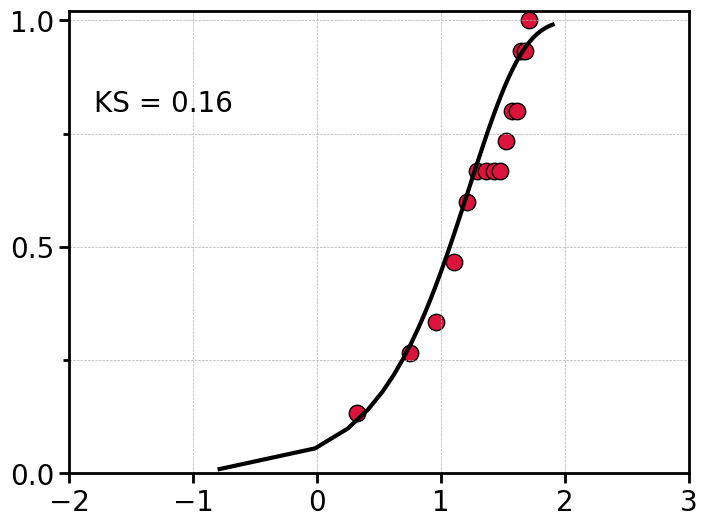

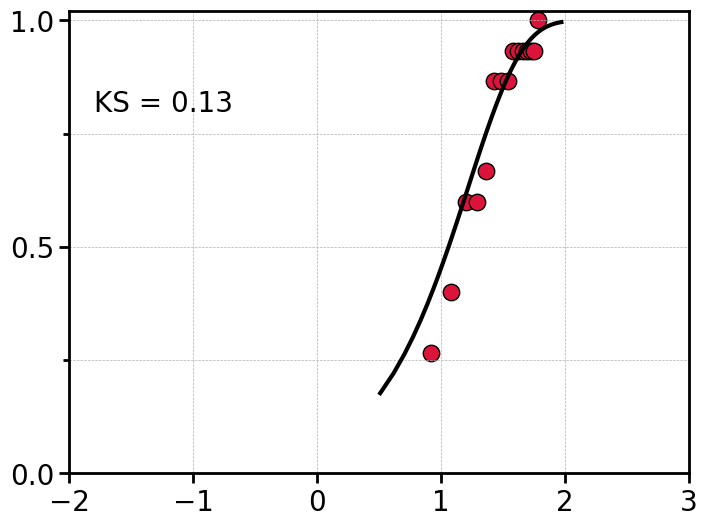

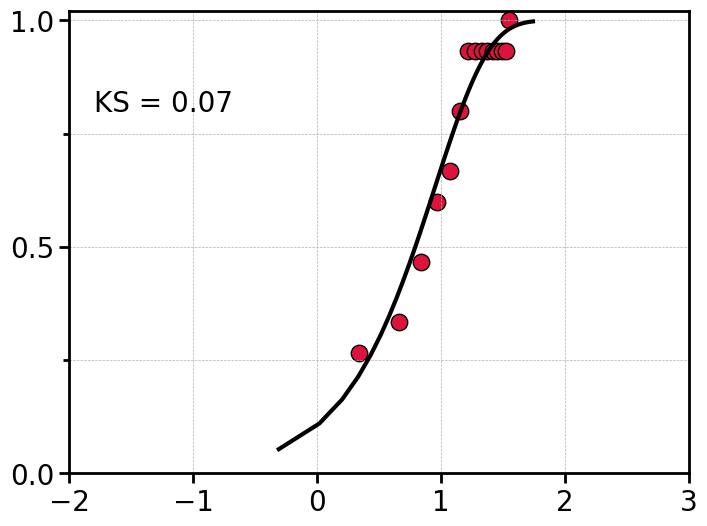

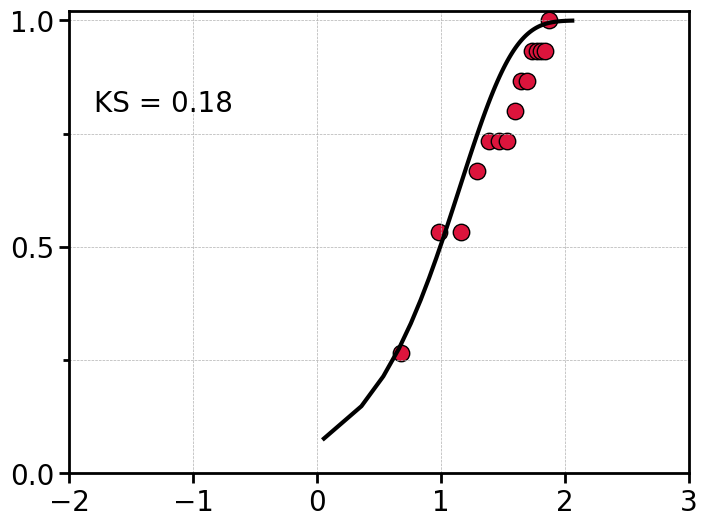

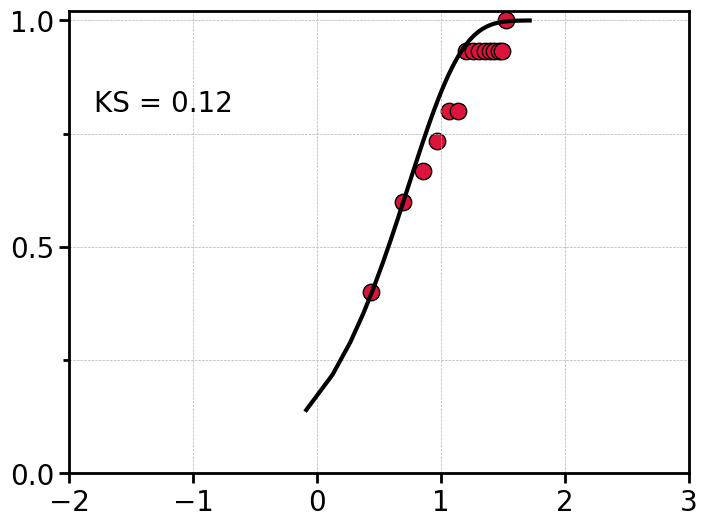

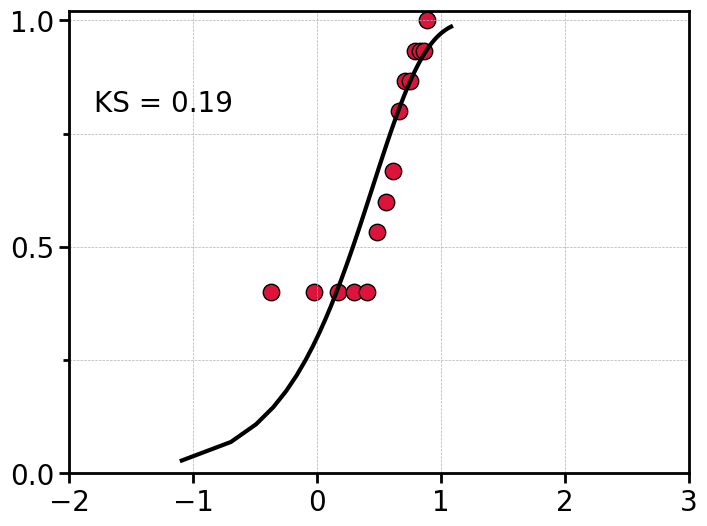

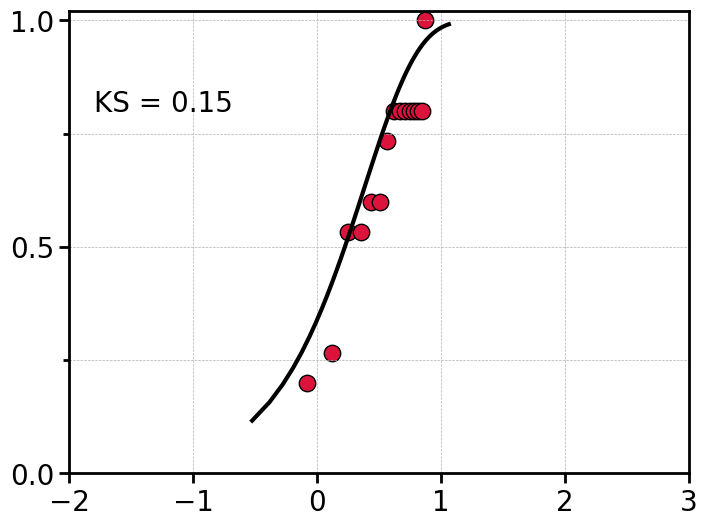

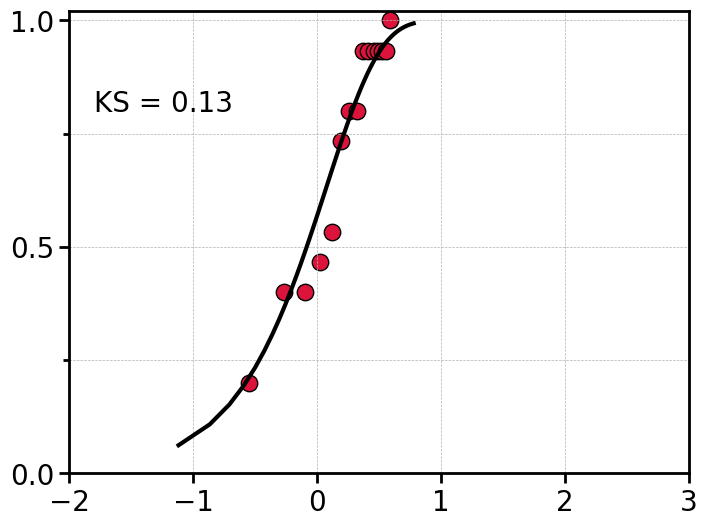

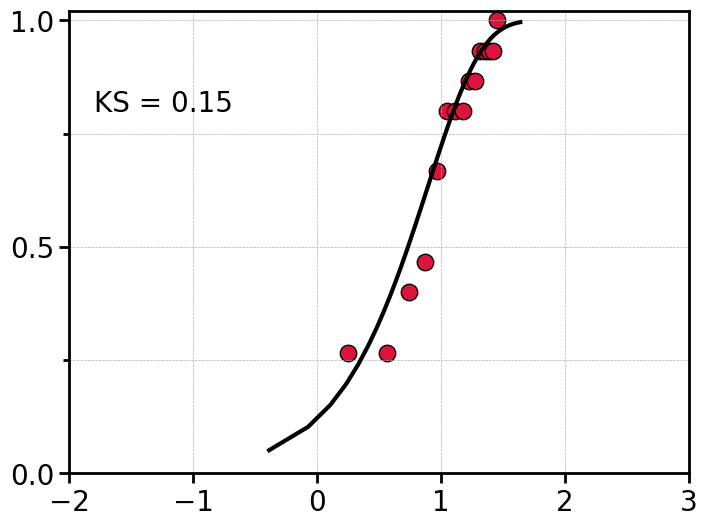

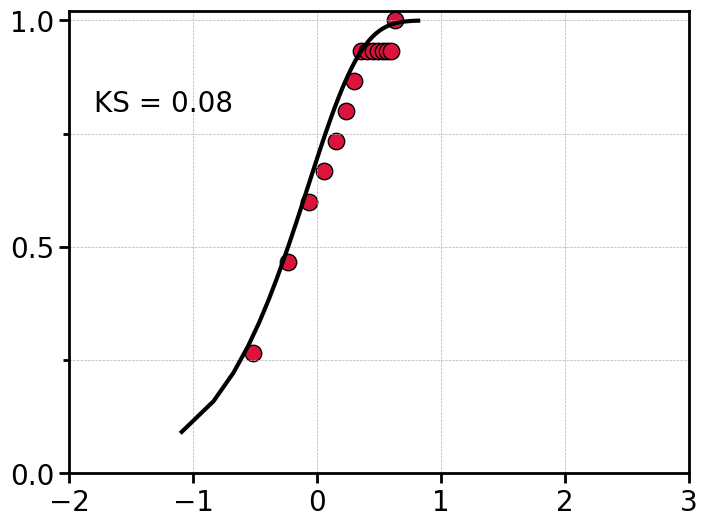

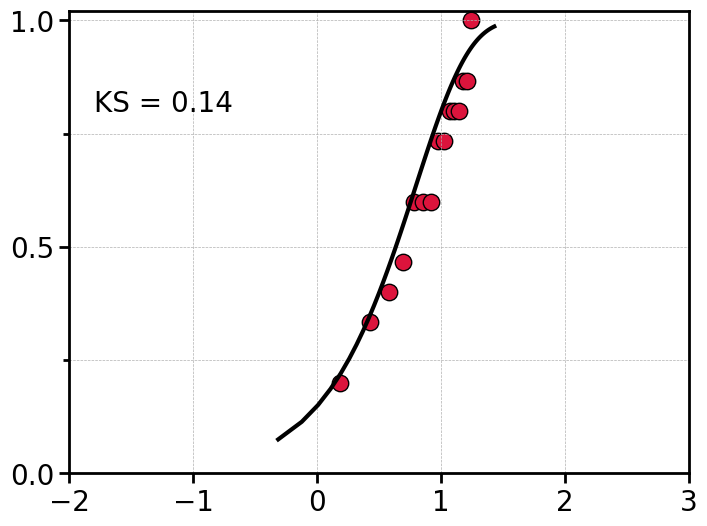

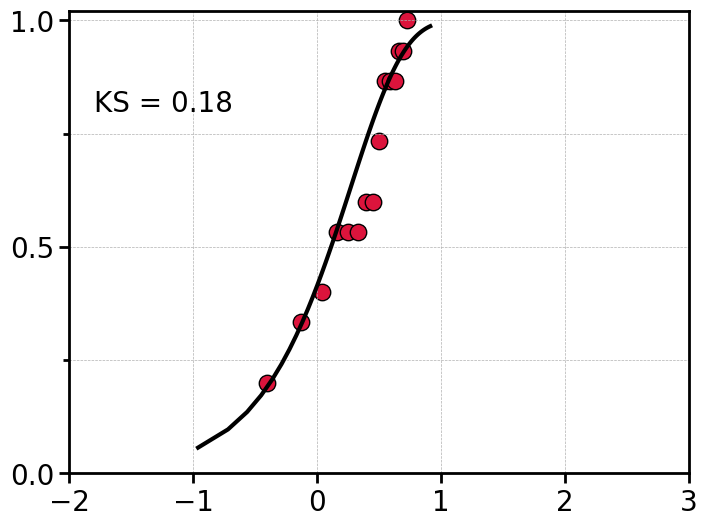

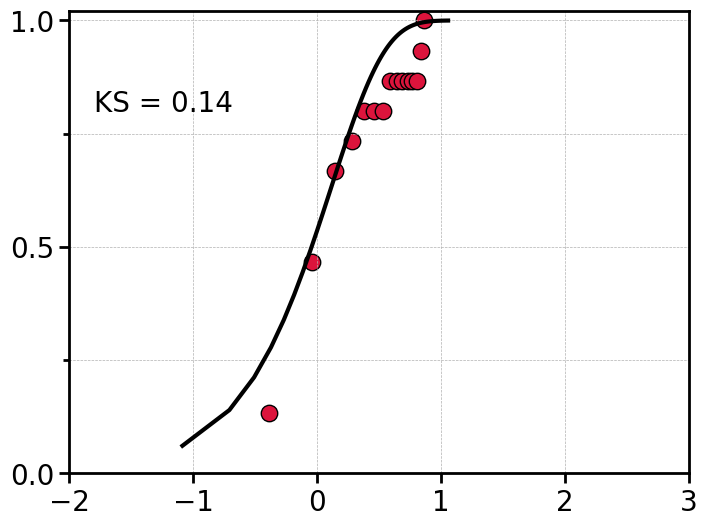

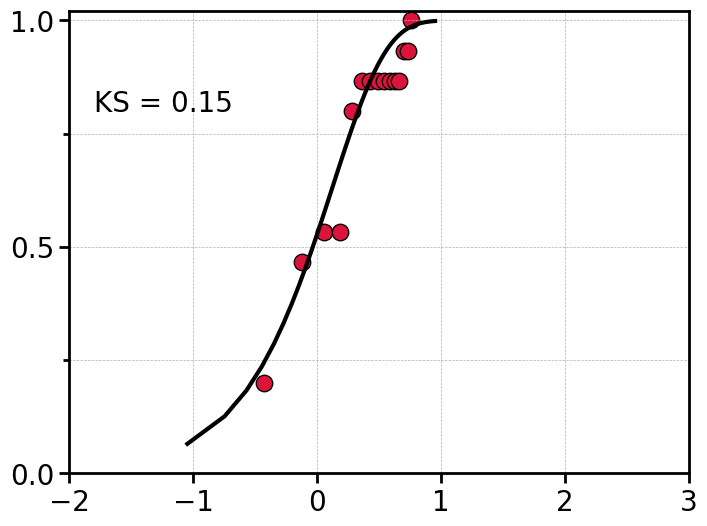

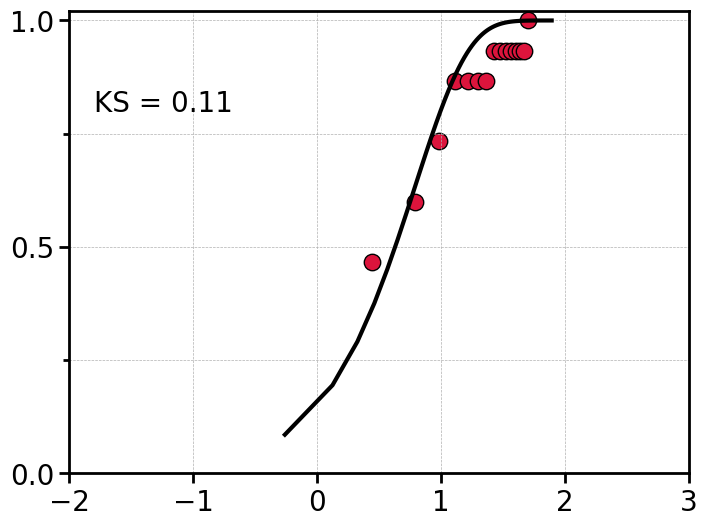

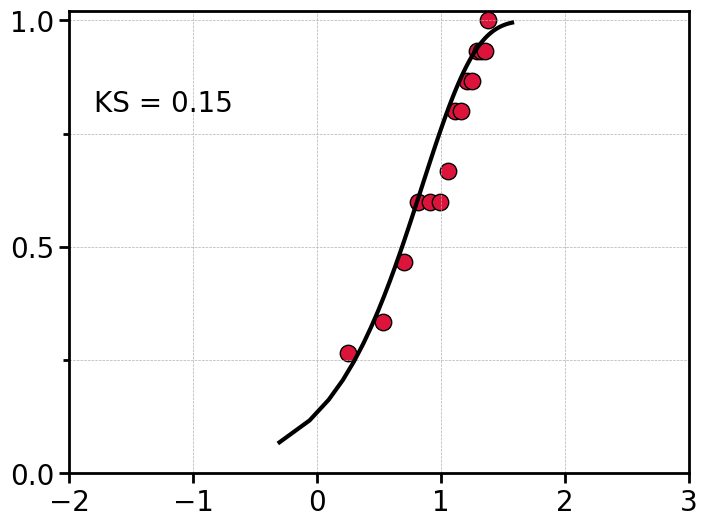

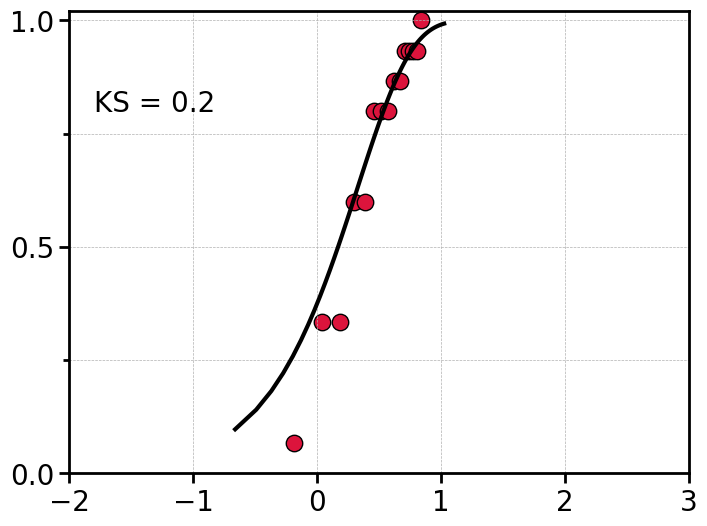

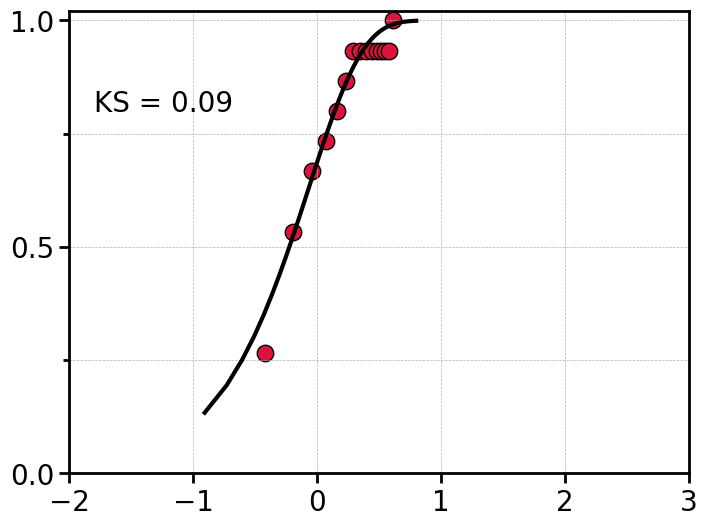

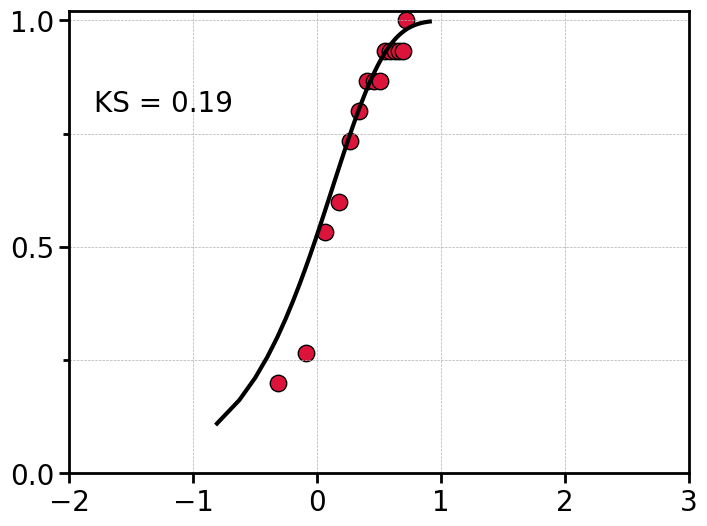

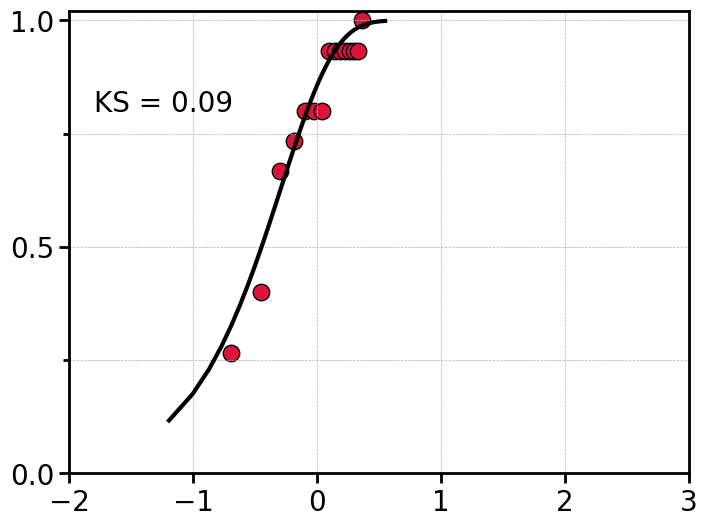

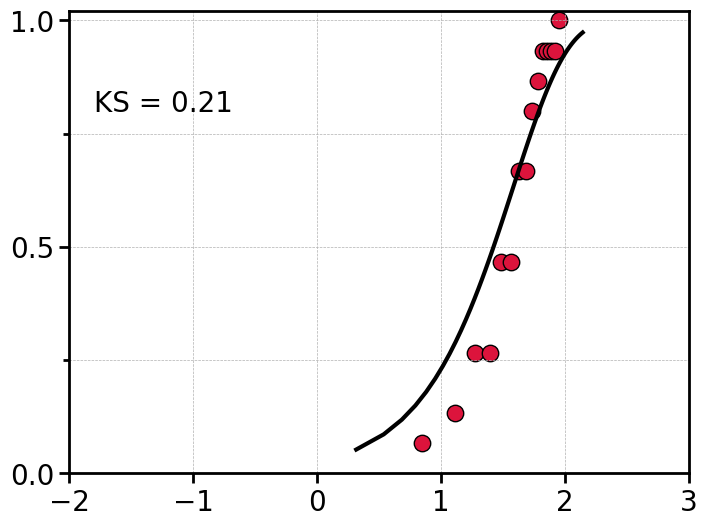

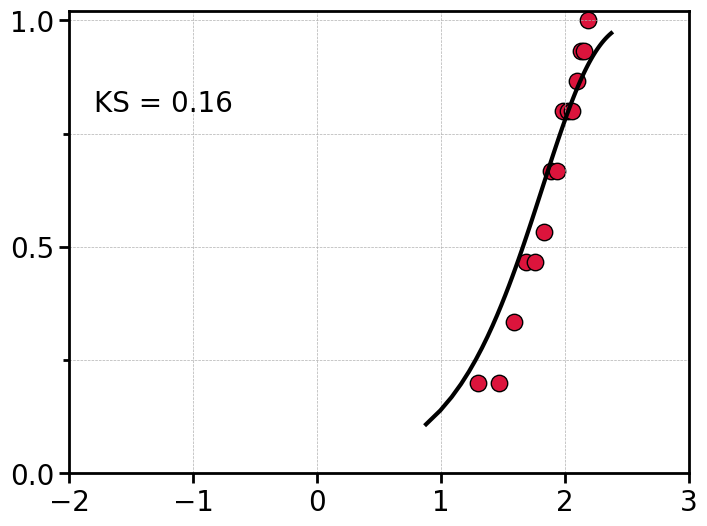

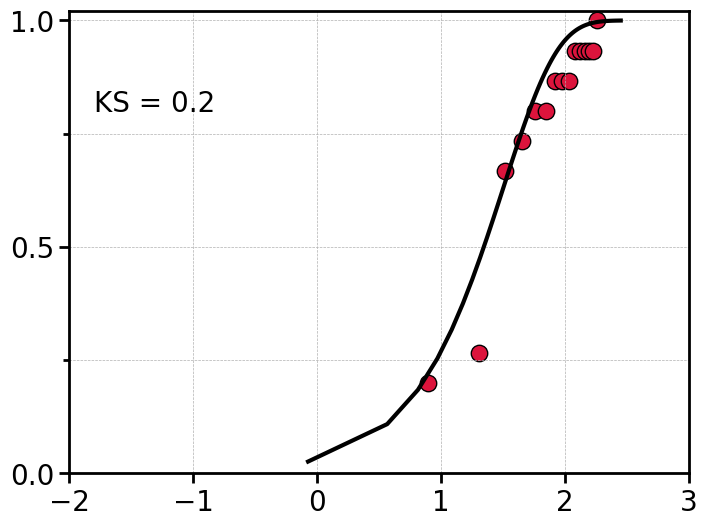

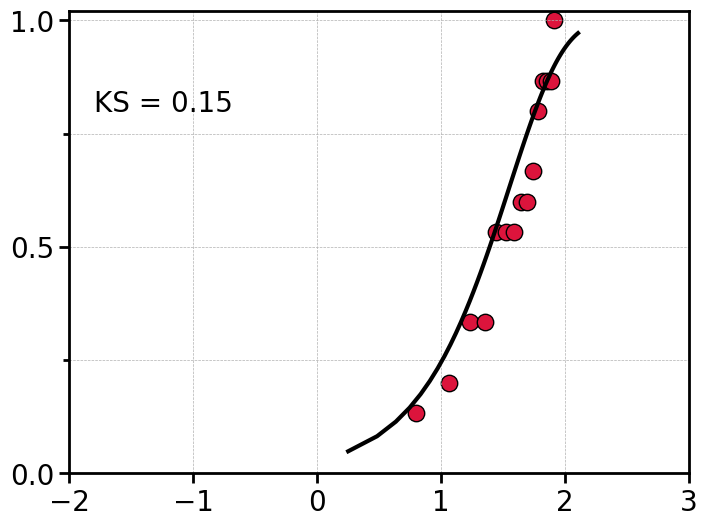

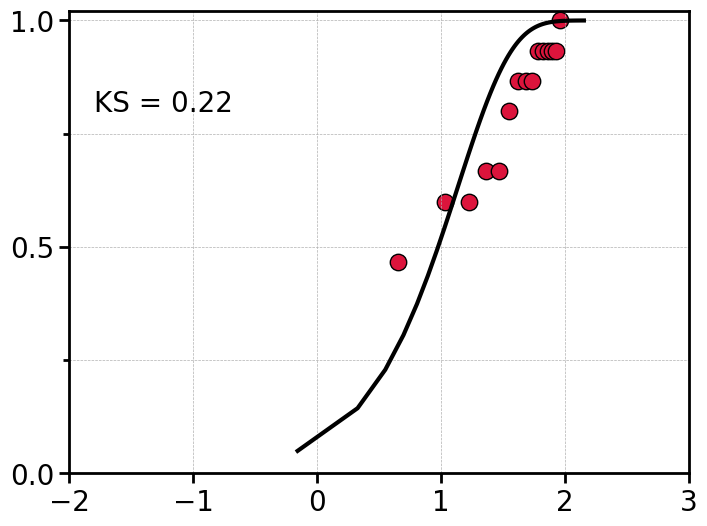

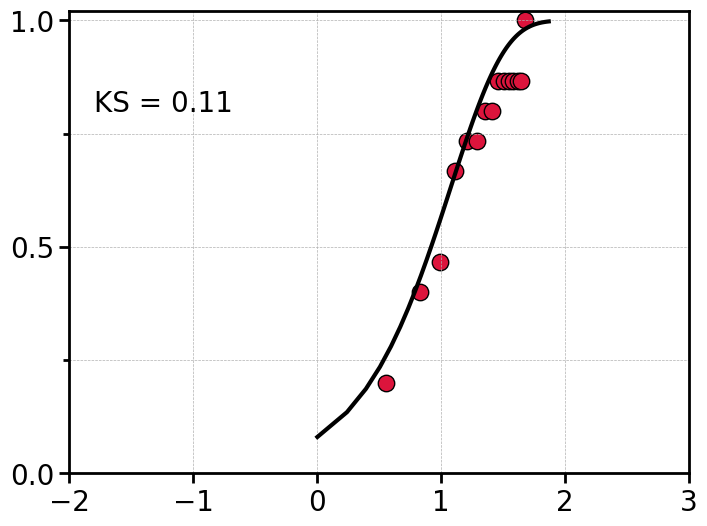

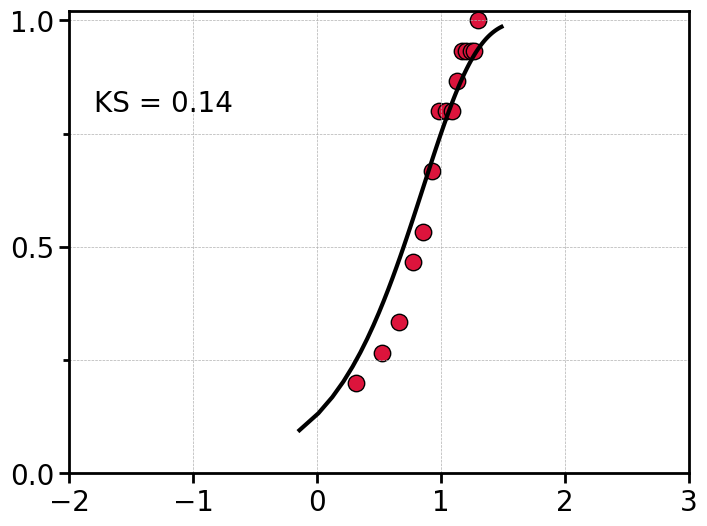

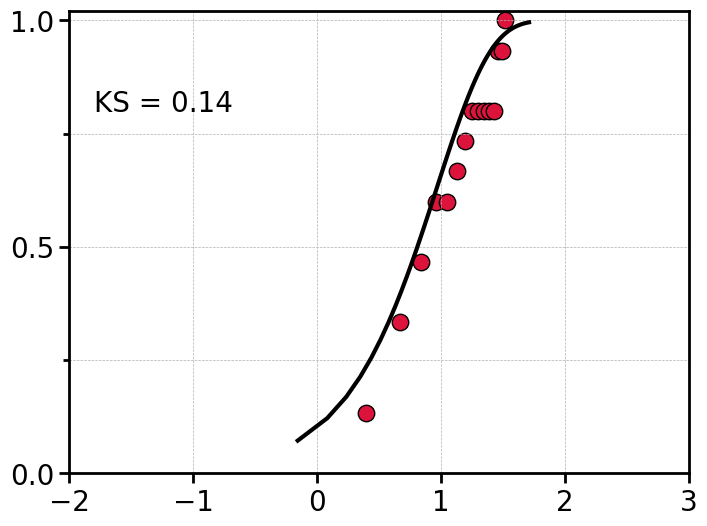

In [38]:
for i in range(len(tbound)):
    fig,ax = plt.subplots(1, figsize=(8,6))
    #
    times = tbound[i]
    mini, maxi, mean = np.min(times), np.max(times), mbound[0][i]
    xp = np.linspace(0.5*mini, 1.5*maxi, 100)
    poisson = 1 - np.exp(-xp/mean)
    npoints = len(times)
    hist, bins = np.histogram(times, bins=npoints)
    bins = bins[1:] - (bins[1]-bins[0])/2
    cumsum = np.cumsum(hist)
    cumsum = cumsum/np.max(cumsum)
    ks = np.round(np.max(np.abs(1-np.exp(-bins/mean)) - cumsum), 2)
    ax.text(-1.8,0.8,f'KS = {np.round(ks,2)}', fontsize=20)
    #
    ax.scatter(np.log10(bins), cumsum, marker='o', color='crimson', edgecolor='black', s=140)
    ax.plot(np.log10(xp), poisson, color='black', lw=3)
    ax.set_ylim(0,1.02)
    ax.set_yticks([0,0.5,1])
    ax.set_xlim(np.log10(0.01), np.log10(1e3))
    ax.set_xticks([-2,-1,0,1,2,3])
    ax.grid(linestyle='--', linewidth=0.5, which='both')
    #
    ax.spines[:].set_linewidth(2)
    ax.tick_params(labelsize=20, width=2, length=7)
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(which='minor', length=4, width=2)
    #
    plt.savefig(f'saved_ramd_/ks_plts/bound/b{i}.pdf')
    plt.show()

0.15


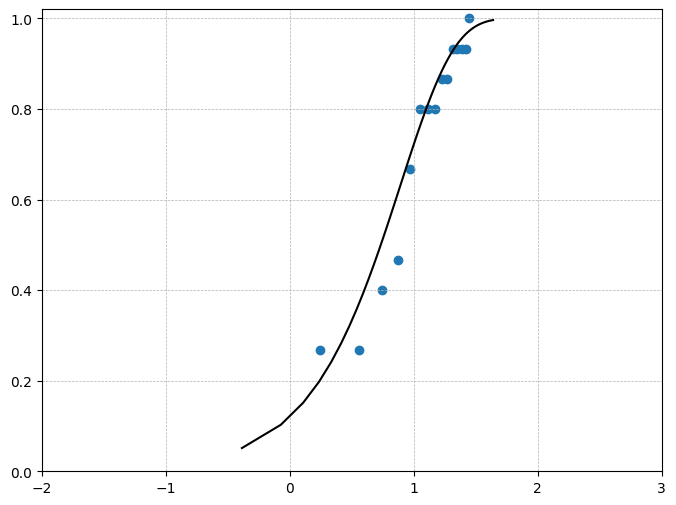

In [296]:
fig,ax = plt.subplots(1, figsize=(8,6))
#
i=12
times = tbound[i]
mini, maxi, mean = np.min(times), np.max(times), mbound[0][i]
xp = np.linspace(0.5*mini, 1.5*maxi, 100)
poisson = 1 - np.exp(-xp/mean)
npoints = len(times)
hist, bins = np.histogram(times, bins=npoints)
bins = bins[1:] - (bins[1]-bins[0])/2
cumsum = np.cumsum(hist)
cumsum = cumsum/np.max(cumsum)
ks = np.round(np.max(np.abs(1-np.exp(-bins/mean)) - cumsum), 2)
#
ax.scatter(np.log10(bins), cumsum, marker='o')
ax.plot(np.log10(xp), poisson, color='k')
ax.set_ylim(0,1.02)
ax.set_xlim(np.log10(0.01), np.log10(1e3))
ax.grid(linestyle='--', linewidth=0.5)
#
print(ks)
plt.show()

In [4]:
def plot_pathway(ref, trj, cutoff, outfile,
                lig='resname GDM', 
                 out_dist=True, max_beta_dist=30, stop=np.inf):
    #
    ofile = open(outfile, 'w')
    for l in open(ref, 'r'):
        if 'ATOM ' in l[:6] and 'GDM' not in l:
            ofile.write(l)
            last = l
    ofile.write('TER \n')
    #
    items = last.strip().split()
    atom = int(items[1])+1   #for next entries
    resid = int(items[4])+1
    #
    u = mda.Universe(ref, trj)
    pos = np.mean(u.select_atoms(lig).positions, axis=0)
    ofile.write(get_line(atom, resid, pos[0], pos[1], pos[2], 0))
    atom += 1
    resid += 1
    #
    prev = [pos]
    ini = pos+0
    tlength = len(u.trajectory)
    for t in range(1, tlength):
        u.trajectory[t]
        pos = np.mean(u.select_atoms(lig).positions, axis=0)
        mindist = np.linalg.norm(np.array(prev) - pos, axis=1).min()
        if mindist > cutoff:
            if out_dist:
                beta = np.linalg.norm(ini-pos)/max_beta_dist
            else:
                beta = t/tlength
                #
            ofile.write(get_line(atom, resid, pos[0], pos[1], pos[2], beta))
            atom += 1
            resid += 1
            prev.append(pos)
        #
        if t > stop:
            break
    #
    ofile.close()


def get_coord(x):
    return (8-(len(f'{x:.3f}')))*' ' + f'{x:.3f}'

def get_line(atom, resid, xc, yc, zc, beta):
    return f'HETATM {atom:04d}  O   HOH   {resid:03d}    {get_coord(xc)}{get_coord(yc)}{get_coord(zc)}  1.00  {beta:4.2f}           O \n'

In [5]:
for b in range(1,64,2):
    for i in range(15):
        plot_pathway('1_bound_confs/relative-residence-time/analysis/pbc_trjs/bound.pdb',
                    f'1_bound_confs/relative-residence-time/analysis/pbc_trjs/b{b}_{i+1}.xtc',
                    2, f'saved_ramd_/pathways/bound/b{b}_{i+1}.pdb'
                    )

In [6]:
for t in [1,2]:
    for k in range(10):
        for i in range(15):
            plot_pathway('2_int_confs/6_analysis/pbc_trjs/bound.pdb',
                        f'2_int_confs/6_analysis/pbc_trjs/t{t}_i{k+1}_{i+1}.xtc',
                        2, f'saved_ramd_/pathways/int/t{t}_i{k+1}_{i+1}.pdb'
                        )